# Burgas integration and transfer experiments

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if not (ROOT / 'reports/burgas').exists(): ROOT = ROOT.parent
display(Markdown((ROOT / 'reports/burgas/conclusions.md').read_text()))

# Бургас: интеграция и проверка пользы

Источник подходит для задачи T3 как **полевые плотности всего плавающего мусора, визуальный учёт**. Добавлены 84 записи за 2021–2023: 8 повторяемых трансект, 21 день, 11 месячных кампаний; 26 настоящих нулей. Это увеличивает черноморский полевой слой с 33 до 117 событий. Эти события не являются пиксельной разметкой и не дают нового F1 детектора.

Интеграция сделана в отдельный исследовательский реестр: **1019 строк, 402 события**, включая исходные 935 строк без изменения их значений. Источник хранится под отдельным measurement_profile, поскольку минимальный обнаруживаемый размер явно не подтверждён. Сходство с DOORS позволяет проверить перенос как гипотезу; одинаковость измерений не доказана.

## Что дал эксперимент

На тех же 33 событиях DOORS и тех же CV-группах MAE контрольной модели **182.82**, после добавления Бургаса в обучение **181.45 шт./км²**. Разница control−augmented **+1.37**, 95% групповой bootstrap **[-3.86; +7.51]**, групп 9. Положительное значение означает улучшение. Контрольные предсказания воспроизвели предыдущий metocean-эксперимент.

| variant           |   n |     MAE |    RMSE |   RMSLE |     R2 |
|:------------------|----:|--------:|--------:|--------:|-------:|
| doors_only        |  33 | 182.817 | 256.306 |   0.876 | -0.256 |
| doors_plus_burgas |  33 | 181.451 | 252.963 |   0.87  | -0.224 |

Модель: координаты и сезон, RF на log1p плотности; метеопризнаки и категории/счётчики предметов не использованы. Все 84 наблюдения Бургаса поступают только в train каждого фолда, DOORS test остаётся тем же. Это проверка переноса между исследованиями, не доказательство универсальной точности или качества спутникового детектора.

Второй опыт: обучение на 56 наблюдениях 2021–2022, проверка на 28 наблюдениях 2023, на тех же трансектах.

| variant            |   n |     MAE |    RMSE |   RMSLE |     R2 |
|:-------------------|----:|--------:|--------:|--------:|-------:|
| train_median       |  28 | 727.429 | 1182.32 |   2.256 | -0.581 |
| location_season_rf |  28 | 695.086 | 1148.83 |   3.078 | -0.493 |

Сильный сдвиг по годам: средняя плотность в 2022 — 120.4, в 2023 — 790.9 шт./км². Авторы обсуждают штормовые события 2023 года. Координаты и сезон сами по себе их не описывают. Нужна проверка переноса между кампаниями; случайное деление строк дало бы слишком лёгкую задачу.

## Качество и смысл полей

- DOI 10.17882/98351, авторы Nikola Bobchev, Dimitar Berov, Ventzislav Karamfilov; организация **IBER-BAS**, проект BRIDGE-BS. Локальный файл побайтно совпадает с опубликованным 107709.txt.
- Total_Items — **шт./км²**, не количество предметов. Код единиц NPKM подтверждён словарём NERC. Плотности сохраняются как опубликованы.
- Длина 2250 м, ширина 6 м, площадь 13 500 м² (=0.0135 км²) подтверждены описанием источника и методикой статьи. Обследованная полоса существенно отличается от одного спутникового пикселя.
- LOCAL_CDI_ID имеет только 8 уникальных значений, поэтому ключ события составлен из станции и полного исходного timestamp. Иначе потерялись бы повторные наблюдения.
- Часовой пояс не задан; время каждой станции повторяется между кампаниями. Подтверждённый UTC оставлен пустым, дата помечена как исходная календарная. Роль точки, концы/треки и фактические времена нужно подтвердить у владельцев.
- Все опубликованные QV у плотностей равны 1. В 12 строках сумма округлённых категорий отличается от total на ±1 шт./км²; total не переписывался.
- Сумма density × nominal area = 456.921 условных предметов, а описание сообщает 502. В 8 строках сочетание плотности и номинальной площади не объясняется простым округлением целого счётчика. Поэтому **сырые числители не восстановлены**; нужен ответ авторов по этому расхождению.
- Нули относятся к обследованной полосе и порогу обнаружения. Они не размечают весь спутниковый кроп как чистую воду. Средняя доля пластика 88.72% не применяется к каждой строке.

## Спутниковые пары

Для **6 из 84 событий** найден Sentinel-2 C1 L2A в тот же календарный день, всего 3 продуктов. Проверено покрытие представительной точки. Это кандидаты: точный UTC полевого учёта, геометрия полосы, локальные облака и блики ещё не подтверждены; tile cloud cover не равен качеству точки. Обучение пиксельного детектора на этих плотностях не запускалось.

## Условия использования

DataCite указывает CC BY 4.0 и на SEANOE есть такой же значок. При этом текст Licence/Utilisation упоминает FP7/H2020 BRIDGE-BS и доступ партнёрам/по запросу до публичного выпуска. Это расхождение сохранено в provenance. Выполнен локальный исследовательский анализ предоставленного файла; внешнее использование и распространение помечены как требующие письменного уточнения у владельцев. Контакты SEANOE: bobchev.nikola@gmail.com, dimitar.berov@gmail.com. Письма не отправлялись.

## Следующий практический шаг

Запросить одним письмом подтверждение лицензии, точность/пояс/роль времени, координатную роль и треки восьми трансект, минимальный размер и расхождение 502 предмета против таблицы. После этого проверить локальное качество спутниковых кандидатов и строить признаки по всей полосе. Плотность трансекты использовать как цель концентрации или пространственно агрегированной модели, а независимую пиксельную разметку получать отдельно.

## Источники

- [SEANOE, DOI и файл](https://www.seanoe.org/data/00872/98351/), [DataCite metadata](https://api.datacite.org/dois/10.17882/98351).
- [Авторская статья и методика, Bobchev et al. 2024](https://zenodo.org/records/14608279).
- [NERC P06 NPKM: number per square kilometre](https://vocab.nerc.ac.uk/collection/P06/current/NPKM/).
- [DEIMS: владелец IBER-BAS и описание мониторинга](https://deims.org/dataset/4831ef9e-cb64-4467-afaa-c8739c26a272).


In [2]:
display(pd.read_csv(ROOT / 'reports/burgas/tables/annual_summary.csv'))

,year,events,mean,median,maximum,zeros
0,2021,16,430.437500,148.0,2296,3
1,2022,40,120.375000,0.0,593,22
2,2023,28,790.857143,425.5,4000,1


In [3]:
display(pd.read_csv(ROOT / 'reports/burgas/tables/campaign_summary.csv'))

,campaign,events,mean,std,zeros
0,2021-09,8,620.250,753.251381,0
1,2021-11,8,240.625,481.142966,3
2,2022-02,8,111.125,181.583068,4
3,2022-04,8,9.250,26.162951,7
4,2022-06,8,268.500,234.104983,2
5,2022-09,8,27.750,55.057762,6
6,2022-11,8,185.250,241.041046,3
7,2023-04,4,333.000,124.560561,0
8,2023-06,8,249.875,287.411322,1
9,2023-09,8,870.250,559.671268,0


In [4]:
display(pd.read_csv(ROOT / 'reports/burgas/tables/density_audit.csv'))

,event_id,source_row_refs,total_minus_category_sum,implied_count_not_raw,raw_integer_count_compatible_with_rounding
0,S5:BURGAS:ML1:2021-09-13T09:00:00,107709.txt line 27,0,2.9970,True
1,S5:BURGAS:ML2:2021-09-13T09:20:00,107709.txt line 28,0,3.9960,True
2,S5:BURGAS:ML3:2021-09-13T09:50:00,107709.txt line 29,0,30.9960,True
3,S5:BURGAS:ML4:2021-09-13T10:10:00,107709.txt line 30,0,13.0005,True
4,S5:BURGAS:ML5:2021-09-14T09:10:00,107709.txt line 31,1,11.0025,True
...,...,...,...,...,...
79,S5:BURGAS:ML4:2023-11-21T10:10:00,107709.txt line 106,0,19.9935,True
80,S5:BURGAS:ML5:2023-11-22T09:10:00,107709.txt line 107,0,1.9980,True
81,S5:BURGAS:ML6:2023-11-22T09:30:00,107709.txt line 108,0,1.9980,True
82,S5:BURGAS:ML7:2023-11-22T09:50:00,107709.txt line 109,0,54.0000,True


In [5]:
display(pd.read_csv(ROOT / 'reports/burgas/tables/burgas_temporal_metrics.csv'))

,variant,n,MAE,RMSE,RMSLE,R2
0,train_median,28,727.428571,1182.324164,2.255860,-0.581313
1,location_season_rf,28,695.085924,1148.830920,3.077933,-0.492990


In [6]:
display(pd.read_csv(ROOT / 'reports/burgas/tables/doors_transfer_metrics.csv'))

,variant,n,MAE,RMSE,RMSLE,R2
0,doors_only,33,182.816986,256.306358,0.876069,-0.256263
1,doors_plus_burgas,33,181.451320,252.962785,0.869700,-0.223701


In [7]:
display(pd.read_csv(ROOT / 'reports/burgas/tables/satellite_inventory.csv'))

,event_id,date,status,error,stac_id,acquisition_utc,tile_cloud_percent,item_url
0,S5:BURGAS:ML1:2021-09-13T09:00:00,2021-09-13,no_same_day_product,NaN,NaN,NaN,NaN,NaN
1,S5:BURGAS:ML2:2021-09-13T09:20:00,2021-09-13,no_same_day_product,NaN,NaN,NaN,NaN,NaN
2,S5:BURGAS:ML3:2021-09-13T09:50:00,2021-09-13,no_same_day_product,NaN,NaN,NaN,NaN,NaN
3,S5:BURGAS:ML4:2021-09-13T10:10:00,2021-09-13,no_same_day_product,NaN,NaN,NaN,NaN,NaN
4,S5:BURGAS:ML5:2021-09-14T09:10:00,2021-09-14,candidate_only_time_geometry_quality_unconfirmed,NaN,S2B_T35TNG_20210914T085720_L2A,2021-09-14T09:08:41.124000Z,38.30817,https://earth-search.aws.element84.com/v1/coll...
...,...,...,...,...,...,...,...,...
80,S5:BURGAS:ML4:2023-11-21T10:10:00,2023-11-21,no_same_day_product,NaN,NaN,NaN,NaN,NaN
81,S5:BURGAS:ML5:2023-11-22T09:10:00,2023-11-22,no_same_day_product,NaN,NaN,NaN,NaN,NaN
82,S5:BURGAS:ML6:2023-11-22T09:30:00,2023-11-22,no_same_day_product,NaN,NaN,NaN,NaN,NaN
83,S5:BURGAS:ML7:2023-11-22T09:50:00,2023-11-22,no_same_day_product,NaN,NaN,NaN,NaN,NaN


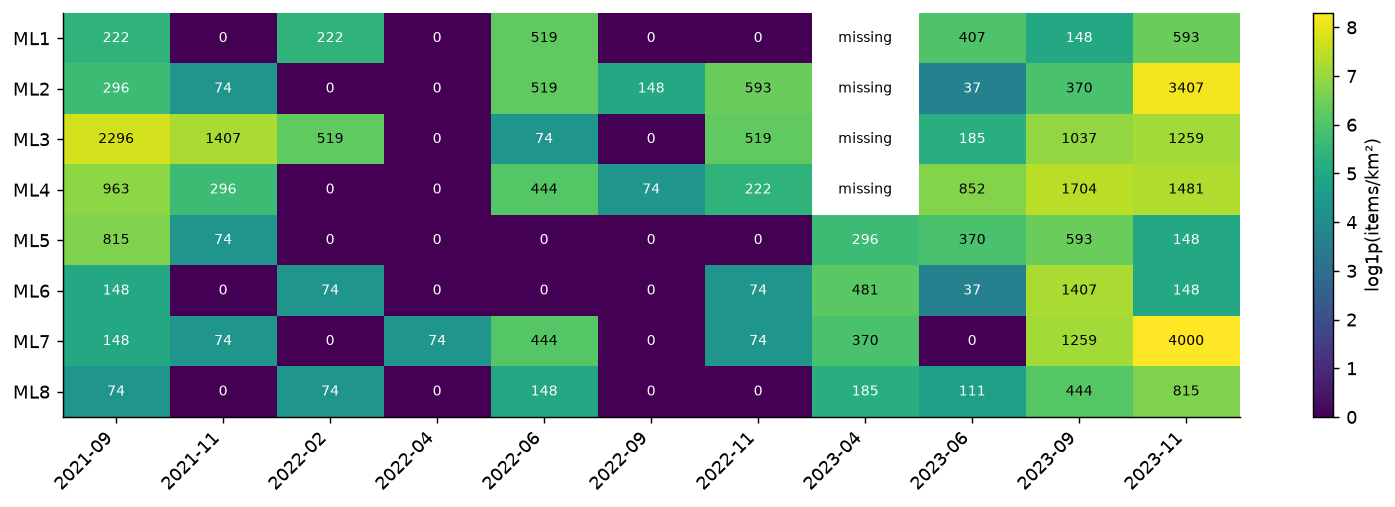

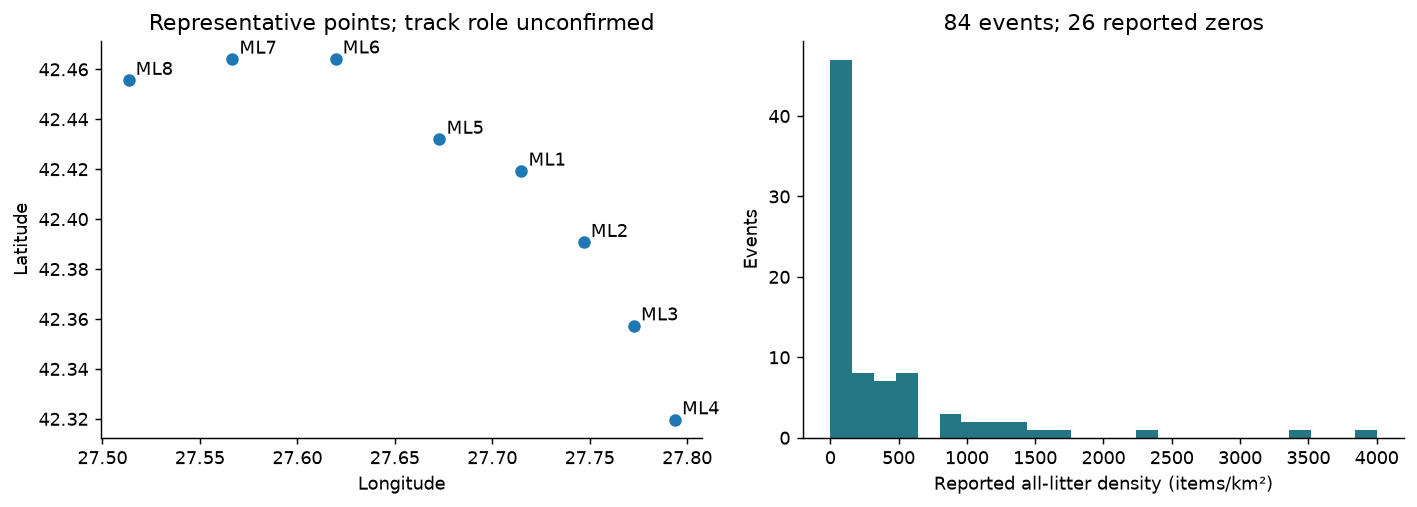

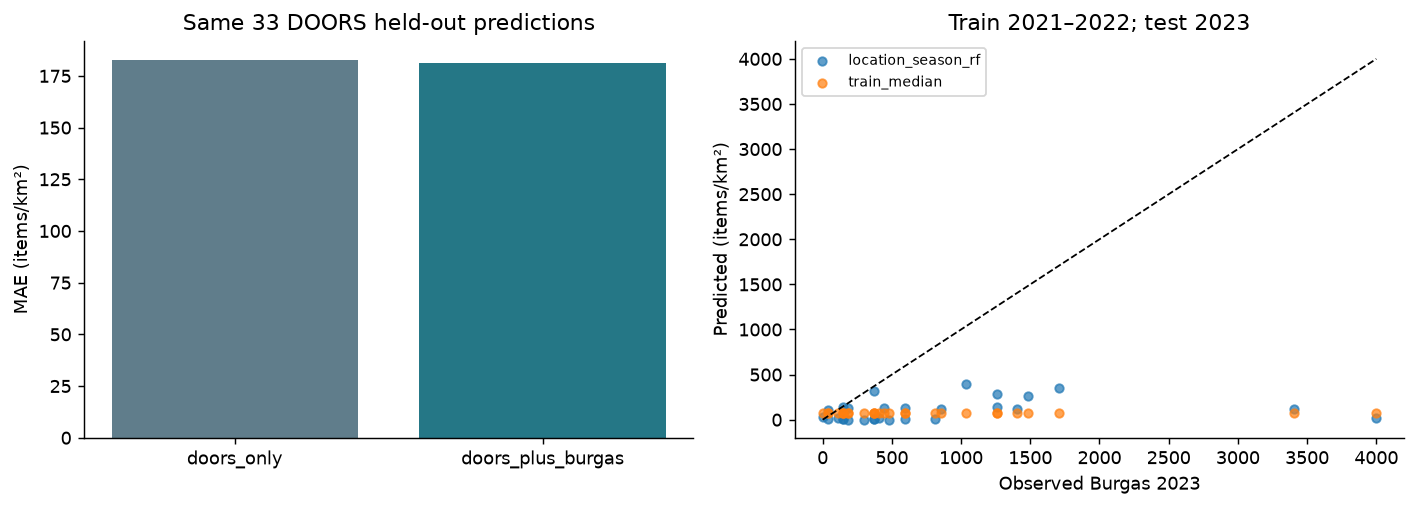

In [8]:
for p in sorted((ROOT / 'reports/burgas/figures').glob('*.png')): display(Image(filename=str(p)))